In [1]:
import torch
import math
from pyDOE import lhs   # or scipy.stats.qmc.LatinHypercube
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import trange
import gc
import logging
from torch.func import jacrev, vmap, hessian, jacfwd
from torch.utils.data import TensorDataset, DataLoader
import random
import torch.nn.init as init
import scipy.io
logging.getLogger("torch").setLevel(logging.ERROR)
np.random.seed(1234)
torch.manual_seed(1234)
device = torch.device('cuda:0')

In [2]:
class DeepMLP(nn.Module):
    def __init__(self, layer_sizes, activation):
        super().__init__()
        self.activation = activation

        weights, biases, scalers = [], [], []
        
        for idx in range(1, len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[idx - 1], layer_sizes[idx]
            if idx == 1:
                weights.append(nn.Parameter(torch.randn(in_dim, out_dim)))
                scalers.append(nn.Parameter(torch.randn(1, out_dim) * 10.0))
                biases.append(nn.Parameter(torch.empty(in_dim, out_dim).uniform_(-1.0, 1.0)))

            else:
                weights.append(nn.Parameter(torch.randn(in_dim, out_dim)))
                biases.append(nn.Parameter(torch.zeros(1, out_dim)))
                

        std = (1.0 / layer_sizes[-2]) ** 0.5
        w = nn.Parameter(torch.randn(layer_sizes[-2], layer_sizes[-1]) * std)
        weights.append(w)
        biases.append(nn.Parameter(torch.zeros(1, layer_sizes[-1])))     

        self.W = nn.ParameterList(weights)
        self.W_a = nn.ParameterList(scalers)
        self.b = nn.ParameterList(biases)
        

    
    def forward(self, x, x_min, x_max):

        features = []
        A = 2.0 * (x - x_min) / (x_max - x_min) - 1.0
        
        for i in range(len(self.W) - 1):
            if i == 0:
                W_temp = self.W_a[i]
                A = self.activation(A @ W_temp - W_temp * self.b[i])
            else:
                A = self.activation(A @ self.W[i] + self.b[i])
        features.append(A)

        y = A @ self.W[-1] + self.b[-1]
        
        return y , features

In [3]:
class Separable3DNet(nn.Module):
    def __init__(self, layer_sizes, activation=torch.tanh):
        super().__init__()
        self.branch_x = DeepMLP(layer_sizes, activation=activation)
        self.branch_y = DeepMLP(layer_sizes, activation=activation)
        self.branch_z = DeepMLP(layer_sizes, activation=activation)
        
        self.final_linear_u = nn.Linear(layer_sizes[-1], 1)        
        std = (1.0/ layer_sizes[-1]) ** 0.5 
        init.normal_(self.final_linear_u.weight, mean=0.0, std=std)
        init.zeros_(self.final_linear_u.bias)
        
        
        self.final_linear_v = nn.Linear(layer_sizes[-1], 1)     
        std = (1.0/ layer_sizes[-1]) ** 0.5 
        init.normal_(self.final_linear_v.weight, mean=0.0, std=std)
        init.zeros_(self.final_linear_v.bias)        

        
        
        self.epsilon_u = nn.Parameter(torch.ones(1, 1, device = device)*(-10))       
        self.epsilon_v = nn.Parameter(torch.ones(1, 1, device = device)*(-10))   
        
        self.FF = nn.Parameter(torch.ones(1, 1, device = device)*(0.05))       
        self.KK = nn.Parameter(torch.ones(1, 1, device = device)*(0.05))   
        
        # defaults assume inputs in [0, 1]; override via set_bounds
        mins = torch.zeros(3, 1)
        maxs = torch.ones(3, 1)
        self.register_buffer("mins", mins)
        self.register_buffer("maxs", maxs)

    def set_bounds(self, mins, maxs):
        """mins/maxs are 3×1 tensors with per-axis min/max."""
        self.mins.copy_(mins)
        self.maxs.copy_(maxs)

    def forward(self, X_star):
        x = X_star[:, 0:1]
        y = X_star[:, 1:2]
        z = X_star[:, 2:3]

        yx, feat_x = self.branch_x(x, self.mins[0:1], self.maxs[0:1])
        yy, feat_y = self.branch_y(y, self.mins[1:2], self.maxs[1:2])
        yz, feat_z = self.branch_z(z, self.mins[2:3], self.maxs[2:3])

        outer_product = yx * yy * yz
        
        y_pred_u = self.final_linear_u(outer_product)
        y_pred_v = self.final_linear_v(outer_product)        
        
        return y_pred_u, y_pred_v

In [4]:
datafile = 'data.npy'
data = np.load(datafile, allow_pickle=True).item()

X = data['X'].astype('float32') 
U = data['U'].astype('float32') 

# Time intervals
tspan = data['tspan']
T1 = data['T1']
T2 = data['T2']

# Parameters
epsilon1 = data['ep1']
epsilon2 = data['ep2']
b = data['b']
d = data['d']

In [5]:
print(T1,T2)

3500 4000


In [6]:
X_star  = torch.from_numpy(X).to(device)
targets = torch.from_numpy(U).to(device)    

layers = [1] + [300] * 5
model = Separable3DNet(layers).to(device)    

mins = torch.tensor([[float(T1)], [-1.0], [-1.0]], device=device)
maxs = torch.tensor([[float(T2)], [1.0], [1.0]], device=device)
model.set_bounds(mins, maxs)


# def init_output_scale(branch, branch_name=None):
#     # 根据分支名称选择不同的axis范围
#     if branch_name == 'branch_x':
#         axis = torch.linspace(T1, T2, 100, dtype=torch.float32, device=device).unsqueeze(1)
#     else:
#         axis = torch.linspace(-1.0, 1.0, 100, dtype=torch.float32, device=device).unsqueeze(1)
    
#     x_min = axis.min(dim=0, keepdim=True).values
#     x_max = axis.max(dim=0, keepdim=True).values

#     with torch.no_grad():
#         y_pref = branch.preforward(axis, x_min, x_max)
#         scale = torch.max(torch.abs(y_pref), dim=0, keepdim=True).values
#         branch.output_scale.copy_(scale)

# # 调用时传入分支名称
# init_output_scale(model.branch_x, 'branch_x')
# init_output_scale(model.branch_y, 'branch_y')
# init_output_scale(model.branch_z, 'branch_z')

In [7]:
with torch.no_grad():
    y_pred_u, y_pred_v = model(X_star[:6*40000,:].to(device))
    
err_u = torch.linalg.norm(y_pred_u - targets[:6*40000,0:1]) / torch.linalg.norm(targets[:6*40000,0:1])
err_v = torch.linalg.norm(y_pred_v - targets[:6*40000,1:2]) / torch.linalg.norm(targets[:6*40000,1:2])
print(f"Error(L2): {err_u:.5e}，Error(L2): {err_v:.5e}")

Error(L2): 1.51037e+00，Error(L2): 5.53819e+00


In [8]:
def compute_data_loss(model, boundary_coords, target_boundary, criterion):
    
    y_pred_u, y_pred_v = model(boundary_coords)        
    
    return criterion(y_pred_u, targets_batch[:,0:1]),criterion(y_pred_v, targets_batch[:,1:2])

def compute_pde_loss(model, coords, criterion):
    coords.requires_grad_(True)    
    
    y_pred_u, y_pred_v = model(coords)      
    
    grad_u = torch.autograd.grad(y_pred_u, coords, grad_outputs = torch.ones_like(y_pred_u), create_graph=True,retain_graph=True)[0] 
    u_t,u_x,u_y  = grad_u[:, 0:1], grad_u[:, 1:2], grad_u[:, 2:3]
    u_xx = torch.autograd.grad(u_x, coords,grad_outputs=torch.ones_like(u_x),create_graph= True,retain_graph=True)[0][:, 1:2]
    u_yy = torch.autograd.grad(u_y, coords,grad_outputs=torch.ones_like(u_y),create_graph= True,retain_graph=True)[0][:, 2:3]    

    grad_v = torch.autograd.grad(y_pred_v, coords, grad_outputs = torch.ones_like(y_pred_v), create_graph=True,retain_graph=True)[0] 
    v_t,v_x,v_y  = grad_v[:, 0:1], grad_v[:, 1:2], grad_v[:, 2:3]
    v_xx = torch.autograd.grad(v_x, coords,grad_outputs=torch.ones_like(v_x),create_graph= True,retain_graph=True)[0][:, 1:2]
    v_yy = torch.autograd.grad(v_y, coords,grad_outputs=torch.ones_like(v_y),create_graph= True,retain_graph=True)[0][:, 2:3]
    
    #注意这里带了括号u_t-()
    res_u =  u_t - (torch.exp(model.epsilon_u) * (u_xx + u_yy) + model.FF * (1 - y_pred_u) -   y_pred_u * y_pred_v * y_pred_v)
    res_v =  v_t - (torch.exp(model.epsilon_v) * (v_xx + v_yy) - (model.FF + model.KK) * y_pred_v + y_pred_u * y_pred_v * y_pred_v)
    
    return criterion(res_u, res_u*0),criterion(res_v, res_v * 0)


In [9]:
loss_history = []
P1 = []
P2 = []
P3 = []
P4 = []

nmax = 200000
N_f = 10000

criterion = nn.MSELoss()
initial_lr = 1.0e-3
alpha = 1e-7 / 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=nmax, eta_min=initial_lr * alpha)


start_start_time = time.time()

start_start_time - time.time()

for n in range(1, nmax + 1):

    random_indices = torch.randint(0, len(X_star), (N_f,))
    X_random_batch = X_star[random_indices]
    targets_batch  = targets[random_indices]

    col1 = torch.rand(N_f, 1) * (T2 - T1) + T1
    col2 = torch.rand(N_f, 1) * 2 - 1
    col3 = torch.rand(N_f, 1) * 2 - 1
    pde_data = torch.cat([col1, col2, col3], dim=1).to(device)    

    optimizer.zero_grad()
    
    loss_u,loss_v = compute_data_loss(model, X_random_batch, targets_batch, criterion)    
    
    res_u,res_v   = compute_pde_loss(model, pde_data,criterion)   
    
    loss   = torch.pow(loss_u,1/4) + torch.pow(loss_v,1/4)  + torch.pow(res_u,1/4) + torch.pow(res_v,1/4)
    
    if n  == 1:
        bx_mean = model.branch_x.b[0].mean().item()
        by_mean = model.branch_y.b[0].mean().item()
        print(f"n: {n}, loss_u: {loss_u.item():.1e}, loss_v: {loss_v.item():.1e},time: {int(time.time() - start_start_time)}")
        print(torch.exp(model.epsilon_u.data), torch.exp(model.epsilon_v.data),model.FF.data,model.KK.data)
        loss_history.append(loss.item())
        P1.append(torch.exp(model.epsilon_u.data))
        P2.append(torch.exp(model.epsilon_v.data))
        P3.append(model.FF.item())
        P4.append(model.KK.item())
        start_start_time = time.time()    
        
    loss.backward()
    optimizer.step()
    scheduler.step()

    if n % 1000 == 0:
        bx_mean = model.branch_x.b[0].mean().item()
        by_mean = model.branch_y.b[0].mean().item()
        print(f"n: {n}, loss_u: {loss_u.item():.1e}, loss_v: {loss_v.item():.1e},time: {int(time.time() - start_start_time)}")
        print(torch.exp(model.epsilon_u.data), torch.exp(model.epsilon_v.data),model.FF.data,model.KK.data)
        loss_history.append(loss.item())
        P1.append(torch.exp(model.epsilon_u.data))
        P2.append(torch.exp(model.epsilon_v.data))
        P3.append(model.FF.item())
        P4.append(model.KK.item())
        start_start_time = time.time()

/home/wangyong/anaconda3/envs/torch/lib/python3.9/site-packages/torch/autograd/graph.py:768: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


n: 1, loss_u: 1.3e+00, loss_v: 9.3e-01,time: 0
tensor([[4.5400e-05]], device='cuda:0') tensor([[4.5400e-05]], device='cuda:0') tensor([[0.0500]], device='cuda:0') tensor([[0.0500]], device='cuda:0')
n: 1000, loss_u: 1.8e-02, loss_v: 8.2e-03,time: 289
tensor([[3.0905e-05]], device='cuda:0') tensor([[3.5277e-05]], device='cuda:0') tensor([[0.0357]], device='cuda:0') tensor([[0.0581]], device='cuda:0')
n: 2000, loss_u: 8.9e-04, loss_v: 6.6e-04,time: 289
tensor([[1.6112e-05]], device='cuda:0') tensor([[1.8950e-05]], device='cuda:0') tensor([[0.0397]], device='cuda:0') tensor([[0.0547]], device='cuda:0')
n: 3000, loss_u: 2.3e-04, loss_v: 1.6e-04,time: 274
tensor([[9.6070e-06]], device='cuda:0') tensor([[9.4468e-06]], device='cuda:0') tensor([[0.0415]], device='cuda:0') tensor([[0.0573]], device='cuda:0')
n: 4000, loss_u: 1.3e-04, loss_v: 9.9e-05,time: 262
tensor([[7.9231e-06]], device='cuda:0') tensor([[6.0609e-06]], device='cuda:0') tensor([[0.0417]], device='cuda:0') tensor([[0.0586]], de

n: 41000, loss_u: 3.5e-05, loss_v: 2.6e-05,time: 122
tensor([[1.7713e-05]], device='cuda:0') tensor([[9.0760e-06]], device='cuda:0') tensor([[0.0402]], device='cuda:0') tensor([[0.0597]], device='cuda:0')
n: 42000, loss_u: 3.6e-05, loss_v: 2.6e-05,time: 122
tensor([[1.7798e-05]], device='cuda:0') tensor([[9.1359e-06]], device='cuda:0') tensor([[0.0403]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 43000, loss_u: 1.0e-03, loss_v: 6.3e-04,time: 122
tensor([[1.0183e-05]], device='cuda:0') tensor([[5.2798e-06]], device='cuda:0') tensor([[0.0407]], device='cuda:0') tensor([[0.0594]], device='cuda:0')
n: 44000, loss_u: 6.4e-05, loss_v: 4.8e-05,time: 122
tensor([[9.0375e-06]], device='cuda:0') tensor([[4.6542e-06]], device='cuda:0') tensor([[0.0418]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 45000, loss_u: 5.6e-05, loss_v: 4.2e-05,time: 122
tensor([[1.2570e-05]], device='cuda:0') tensor([[6.3715e-06]], device='cuda:0') tensor([[0.0411]], device='cuda:0') tensor([[0.

n: 81000, loss_u: 2.0e-05, loss_v: 1.8e-05,time: 122
tensor([[1.8818e-05]], device='cuda:0') tensor([[9.6092e-06]], device='cuda:0') tensor([[0.0401]], device='cuda:0') tensor([[0.0598]], device='cuda:0')
n: 82000, loss_u: 2.1e-05, loss_v: 1.8e-05,time: 122
tensor([[1.8792e-05]], device='cuda:0') tensor([[9.5884e-06]], device='cuda:0') tensor([[0.0400]], device='cuda:0') tensor([[0.0598]], device='cuda:0')
n: 83000, loss_u: 1.9e-05, loss_v: 1.6e-05,time: 122
tensor([[1.8856e-05]], device='cuda:0') tensor([[9.6223e-06]], device='cuda:0') tensor([[0.0402]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 84000, loss_u: 1.7e-05, loss_v: 1.6e-05,time: 122
tensor([[1.8855e-05]], device='cuda:0') tensor([[9.6199e-06]], device='cuda:0') tensor([[0.0401]], device='cuda:0') tensor([[0.0598]], device='cuda:0')
n: 85000, loss_u: 2.0e-05, loss_v: 1.6e-05,time: 122
tensor([[1.8874e-05]], device='cuda:0') tensor([[9.6312e-06]], device='cuda:0') tensor([[0.0401]], device='cuda:0') tensor([[0.

n: 121000, loss_u: 1.0e-05, loss_v: 1.0e-05,time: 218
tensor([[1.9329e-05]], device='cuda:0') tensor([[9.8323e-06]], device='cuda:0') tensor([[0.0401]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 122000, loss_u: 9.8e-06, loss_v: 1.1e-05,time: 218
tensor([[1.9354e-05]], device='cuda:0') tensor([[9.8459e-06]], device='cuda:0') tensor([[0.0401]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 123000, loss_u: 9.2e-06, loss_v: 1.0e-05,time: 213
tensor([[1.9350e-05]], device='cuda:0') tensor([[9.8361e-06]], device='cuda:0') tensor([[0.0401]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 124000, loss_u: 9.1e-06, loss_v: 9.9e-06,time: 122
tensor([[1.9349e-05]], device='cuda:0') tensor([[9.8395e-06]], device='cuda:0') tensor([[0.0401]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 125000, loss_u: 9.4e-06, loss_v: 9.6e-06,time: 122
tensor([[1.9365e-05]], device='cuda:0') tensor([[9.8460e-06]], device='cuda:0') tensor([[0.0401]], device='cuda:0') tensor

n: 161000, loss_u: 4.4e-06, loss_v: 7.3e-06,time: 122
tensor([[1.9540e-05]], device='cuda:0') tensor([[9.9204e-06]], device='cuda:0') tensor([[0.0400]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 162000, loss_u: 4.2e-06, loss_v: 6.9e-06,time: 179
tensor([[1.9541e-05]], device='cuda:0') tensor([[9.9239e-06]], device='cuda:0') tensor([[0.0400]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 163000, loss_u: 4.0e-06, loss_v: 7.0e-06,time: 214
tensor([[1.9550e-05]], device='cuda:0') tensor([[9.9270e-06]], device='cuda:0') tensor([[0.0400]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 164000, loss_u: 4.3e-06, loss_v: 7.0e-06,time: 214
tensor([[1.9550e-05]], device='cuda:0') tensor([[9.9261e-06]], device='cuda:0') tensor([[0.0400]], device='cuda:0') tensor([[0.0599]], device='cuda:0')
n: 165000, loss_u: 4.2e-06, loss_v: 7.0e-06,time: 214
tensor([[1.9552e-05]], device='cuda:0') tensor([[9.9273e-06]], device='cuda:0') tensor([[0.0401]], device='cuda:0') tensor

In [10]:
        print(f"FF: {model.FF.item():.10f}")
        print(f"KK: {model.KK.item():.10f}")

FF: 0.0400312208
KK: 0.0598797314


In [11]:
batch_size = 40000
num_batches =  int((T2-T1)/10)

for batch_num in range(num_batches):
    start_idx = batch_num * batch_size
    end_idx = (batch_num + 1) * batch_size
    
    with torch.no_grad():
        y_pred_u, y_pred_v = model(X_star[start_idx:end_idx, :].to(device))
    
    # 计算当前批次的误差
    err_u = torch.linalg.norm(y_pred_u - targets[start_idx:end_idx, 0:1]) / torch.linalg.norm(targets[start_idx:end_idx, 0:1])
    err_v = torch.linalg.norm(y_pred_v - targets[start_idx:end_idx, 1:2]) / torch.linalg.norm(targets[start_idx:end_idx, 1:2])
    
    print(f"Batch {batch_num} - Error_u: {err_u:.5e}, Error_v: {err_v:.5e}")

Batch 0 - Error_u: 4.51601e-03, Error_v: 2.20527e-02
Batch 1 - Error_u: 3.05969e-03, Error_v: 1.74880e-02
Batch 2 - Error_u: 2.13578e-03, Error_v: 1.50609e-02
Batch 3 - Error_u: 1.86438e-03, Error_v: 1.42761e-02
Batch 4 - Error_u: 2.00345e-03, Error_v: 1.42788e-02
Batch 5 - Error_u: 2.20174e-03, Error_v: 1.43911e-02
Batch 6 - Error_u: 2.31258e-03, Error_v: 1.43242e-02
Batch 7 - Error_u: 2.31367e-03, Error_v: 1.40409e-02
Batch 8 - Error_u: 2.23636e-03, Error_v: 1.36582e-02
Batch 9 - Error_u: 2.12747e-03, Error_v: 1.33289e-02
Batch 10 - Error_u: 2.02775e-03, Error_v: 1.31533e-02
Batch 11 - Error_u: 1.97113e-03, Error_v: 1.31497e-02
Batch 12 - Error_u: 1.96969e-03, Error_v: 1.32529e-02
Batch 13 - Error_u: 2.01184e-03, Error_v: 1.33622e-02
Batch 14 - Error_u: 2.07266e-03, Error_v: 1.33807e-02
Batch 15 - Error_u: 2.12593e-03, Error_v: 1.32536e-02
Batch 16 - Error_u: 2.15341e-03, Error_v: 1.29998e-02
Batch 17 - Error_u: 2.14929e-03, Error_v: 1.26784e-02
Batch 18 - Error_u: 2.12837e-03, Error

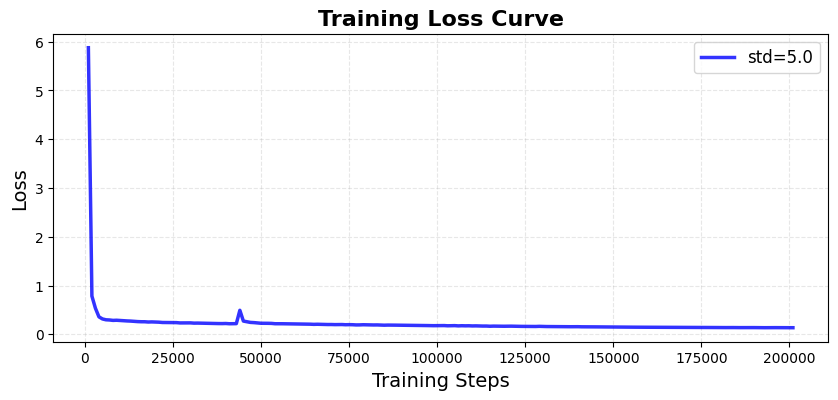

In [12]:
steps = [(i + 1) * 1000 for i in range(len(loss_history))]

plt.figure(figsize=(10, 4))
plt.plot(steps, loss_history, "b-", linewidth=2.5, alpha=0.8, label="std=5.0")

if max(loss_history) / min(loss_history) > 100:
    plt.yscale("log")
    ylabel = "Loss (log scale)"
else:
    ylabel = "Loss"

plt.xlabel("Training Steps", fontsize=14)
plt.ylabel(ylabel, fontsize=14)
plt.title("Training Loss Curve", fontsize=16, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(fontsize=12)
plt.show()


Error(L2): 3.41450e-01，Error(L2): 5.92463e-01


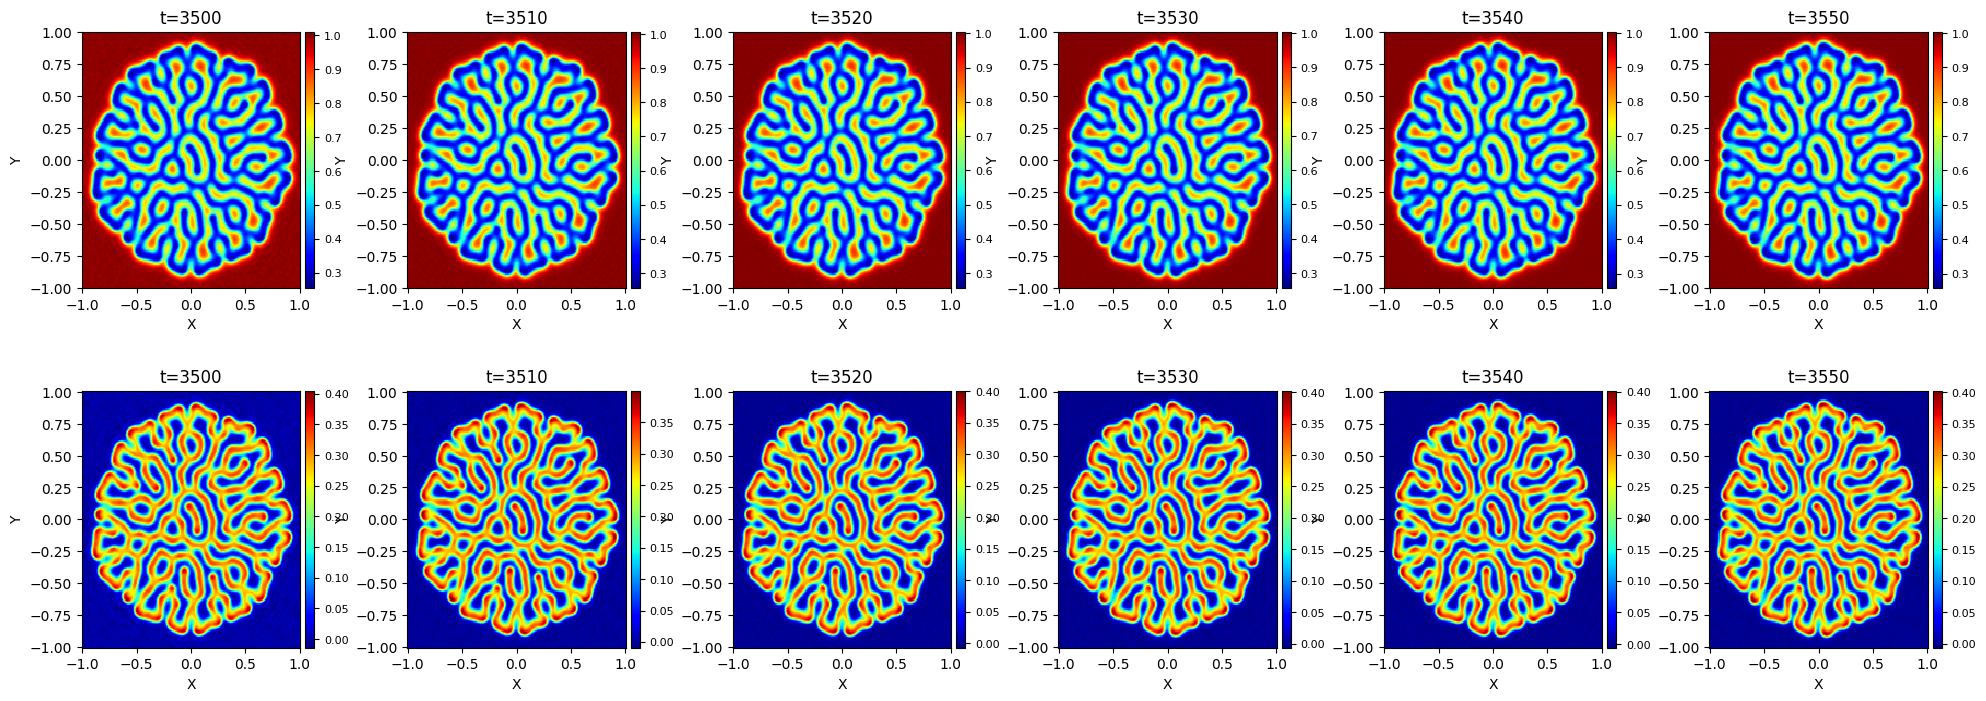

In [13]:
with torch.no_grad():
    y_pred_u, y_pred_v = model(X_star[0:6*40000,:].to(device))
    
err_u = torch.linalg.norm(y_pred_u - targets[-6*40000:,0:1]) / torch.linalg.norm(targets[-6*40000:,0:1])
err_v = torch.linalg.norm(y_pred_v - targets[-6*40000:,1:2]) / torch.linalg.norm(targets[-6*40000:,1:2])
print(f"Error(L2): {err_u:.5e}，Error(L2): {err_v:.5e}")

y_pred_paint = torch.cat([y_pred_u, y_pred_v], dim=1).cpu().numpy()
n_samples_per_time = 40000
n_times = int((T2 - T1)/10) + 1
n_features = 3

X_grouped = X.reshape(n_times, n_samples_per_time, n_features)
X_reshaped = X_grouped.transpose(1, 2, 0)
X_reshaped = X_reshaped[:, 1:3, :]
X_new = X_reshaped.reshape(200, 200, 2, n_times)


U_grouped = y_pred_paint.reshape(6, n_samples_per_time, 2)
U_reshaped = U_grouped.transpose(1, 2, 0)
U_new = U_reshaped.reshape(200, 200, 2, 6)

from mpl_toolkits.axes_grid1 import make_axes_locatable

a_values = [x * 1 for x in [0, 1, 2, 3, 4, 5]]
fig, axs = plt.subplots(2, 6, figsize=(24, 8))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

for col, a in enumerate(a_values):
    for row in range(2):
        ax = axs[row, col]
        h = ax.pcolor(
            X_new[:, :, 0, 0],
            X_new[:, :, 1, 0],
            U_new[:, :, row, a],
            shading='auto',
            cmap='jet'
        )
        ax.set_title(f't={T1+10*a}')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="4%", pad=0.05)
        cbar = fig.colorbar(h, cax=cax)
        cbar.ax.tick_params(labelsize=8)

plt.show()

In [14]:
print(torch.exp(model.epsilon_u.data), torch.exp(model.epsilon_v.data))

tensor([[1.9599e-05]], device='cuda:0') tensor([[9.9467e-06]], device='cuda:0')


In [15]:
datafile = 'data.npy'
data = np.load(datafile, allow_pickle=True).item()

X = data['X'].astype('float32') 
U = data['U'].astype('float32') 

# Time intervals
tspan = data['tspan']
T1 = data['T1']
T2 = data['T2']

# Parameters
epsilon1 = data['ep1']
epsilon2 = data['ep2']
b = data['b']
d = data['d']

X_star  = torch.from_numpy(X).to(device)

In [16]:
batch_size = 40000
num_batches =  int((T2-T1)/10)

y_pred_u_save,y_pred_v_save = [],[]

for batch_num in range(num_batches+1):
    start_idx = batch_num * batch_size
    end_idx = (batch_num + 1) * batch_size
    
    with torch.no_grad():
        y_pred_u, y_pred_v = model(X_star[start_idx:end_idx, :].to(device))
    
    y_pred_u_save.append(y_pred_u)
    y_pred_v_save.append(y_pred_v)

In [17]:
y_pred_u_combined = torch.cat(y_pred_u_save, dim=0)
y_pred_u_combined = y_pred_u_combined.cpu().numpy()
print(y_pred_u_combined.shape) 

y_pred_v_combined = torch.cat(y_pred_v_save, dim=0)
y_pred_v_combined = y_pred_v_combined.cpu().numpy()
print(y_pred_v_combined.shape) 

scipy.io.savemat("y_u.mat", {'u': y_pred_u_combined}) 
scipy.io.savemat("y_v.mat", {'u': y_pred_v_combined}) 

(2040000, 1)
(2040000, 1)


In [18]:
# 将每个列表中的张量移到 CPU
p1_cpu = [t.cpu() if isinstance(t, torch.Tensor) else t for t in P1]
p2_cpu = [t.cpu() if isinstance(t, torch.Tensor) else t for t in P2]
p3_cpu = [t.cpu() if isinstance(t, torch.Tensor) else t for t in P3]
p4_cpu = [t.cpu() if isinstance(t, torch.Tensor) else t for t in P4]

# 保存到 .mat 文件
scipy.io.savemat("data.mat", {
    'p1': p1_cpu,
    'p2': p2_cpu,
    'p3': p3_cpu,
    'p4': p4_cpu
})